<a href="https://colab.research.google.com/github/ayrabia/CS171_GroupProject/blob/main/BrainTumorMRI_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Brain Tumor MRI Classification
**CS171 Final Project — Sean Elopre · Ayman Rabia · Harshit Jaglan**



## 1. GPU Check + Global Seeds

In [1]:
import os
import random
import numpy as np
import tensorflow as tf

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Defined here so it's available to all plotting functions throughout the notebook
DISPLAY_NAMES = {'glioma': 'Glioma', 'meningioma': 'Meningioma',
                 'notumor': 'No Tumor', 'pituitary': 'Pituitary'}

gpus = tf.config.list_physical_devices('GPU')
print('GPUs available:', gpus)
print('TensorFlow version:', tf.__version__)

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow version: 2.20.0


## 2. Mount Google Drive
All outputs (model weights, histories, plots) are saved here so they persist after the session ends.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

OUTPUT_DIR = '/content/drive/MyDrive/CS171_BrainTumor'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print('Output directory:', OUTPUT_DIR)

Mounted at /content/drive
Output directory: /content/drive/MyDrive/CS171_BrainTumor


In [3]:
os.environ['KAGGLE_API_TOKEN'] = 'PASTE_YOUR_TOKEN_HERE'

!pip install -q kaggle

if not os.path.exists('data/Training'):
    !kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset
    !unzip -q brain-tumor-mri-dataset.zip -d data
    print('Dataset downloaded and extracted.')
else:
    print('Dataset already exists, skipping download.')

print('Training dir:', os.listdir('data/Training'))
print('Testing dir :', os.listdir('data/Testing'))

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:01<00:00, 145MB/s]

Dataset downloaded and extracted.
Training dir: ['pituitary', 'notumor', 'meningioma', 'glioma']
Testing dir : ['pituitary', 'notumor', 'meningioma', 'glioma']


## 4. Preprocessing
Shared pipeline used by all three models — ensures a fair apples-to-apples comparison.
Matches `preprocessing.py` exactly.

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE         = (224, 224)
BATCH_SIZE       = 32
VALIDATION_SPLIT = 0.2
TRAIN_DIR        = 'data/Training'
TEST_DIR         = 'data/Testing'


def get_train_generator(train_dir=TRAIN_DIR, batch_size=BATCH_SIZE):
    train_datagen = ImageDataGenerator(
        rescale=1.0 / 255,
        horizontal_flip=True,
        rotation_range=10,
        zoom_range=0.1,
        brightness_range=[0.9, 1.1],
        validation_split=VALIDATION_SPLIT,
    )
    return train_datagen.flow_from_directory(
        train_dir,
        target_size=IMG_SIZE,
        batch_size=batch_size,
        class_mode='categorical',
        subset='training',
        shuffle=True,
        seed=SEED,
    )


def get_val_generator(train_dir=TRAIN_DIR, batch_size=BATCH_SIZE):
    val_datagen = ImageDataGenerator(
        rescale=1.0 / 255,
        validation_split=VALIDATION_SPLIT,
    )
    return val_datagen.flow_from_directory(
        train_dir,
        target_size=IMG_SIZE,
        batch_size=batch_size,
        class_mode='categorical',
        subset='validation',
        shuffle=False,
        seed=SEED,
    )


def get_test_generator(test_dir=TEST_DIR, batch_size=BATCH_SIZE):
    test_datagen = ImageDataGenerator(rescale=1.0 / 255)
    return test_datagen.flow_from_directory(
        test_dir,
        target_size=IMG_SIZE,
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=False,
    )


def get_data_loaders(train_dir=TRAIN_DIR, test_dir=TEST_DIR, batch_size=BATCH_SIZE):
    train_gen  = get_train_generator(train_dir, batch_size)
    val_gen    = get_val_generator(train_dir, batch_size)
    test_gen   = get_test_generator(test_dir, batch_size)
    class_names = [k for k, v in sorted(train_gen.class_indices.items(), key=lambda x: x[1])]
    return train_gen, val_gen, test_gen, class_names


train_gen, val_gen, test_gen, CLASS_NAMES = get_data_loaders()
print('Classes        :', CLASS_NAMES)
print('Training images:', train_gen.samples)
print('Val images     :', val_gen.samples)
print('Test images    :', test_gen.samples)
batch_x, batch_y = next(train_gen)
print(f'Batch shape    : {batch_x.shape}  Pixel range: [{batch_x.min():.1f}, {batch_x.max():.1f}]')

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
Classes        : ['glioma', 'meningioma', 'notumor', 'pituitary']
Training images: 4480
Val images     : 1120
Test images    : 1600
Batch shape    : (32, 224, 224, 3)  Pixel range: [0.0, 1.0]


## 5. Class Distribution

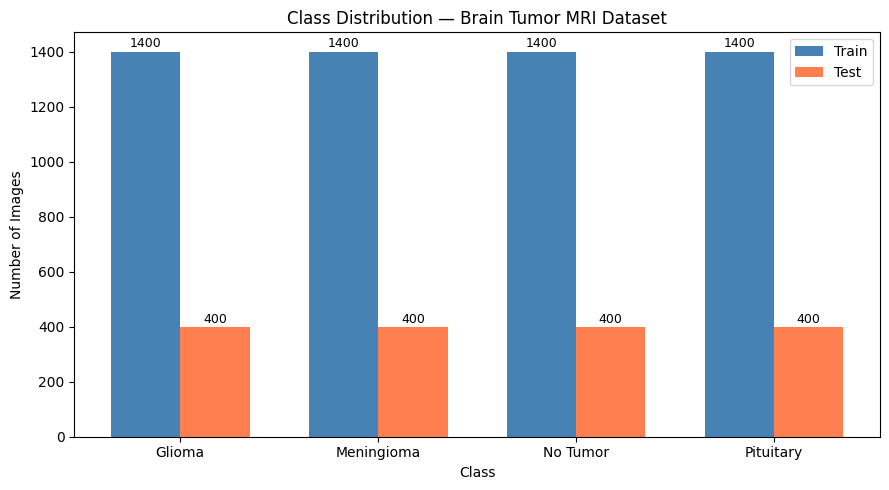

Saved: /content/drive/MyDrive/CS171_BrainTumor/class_distribution.png


In [5]:
import matplotlib.pyplot as plt

train_counts = [len(os.listdir(os.path.join(TRAIN_DIR, c))) for c in CLASS_NAMES]
test_counts  = [len(os.listdir(os.path.join(TEST_DIR,  c))) for c in CLASS_NAMES]
labels       = [DISPLAY_NAMES[c] for c in CLASS_NAMES]

x     = np.arange(len(CLASS_NAMES))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width / 2, train_counts, width, label='Train', color='steelblue')
bars2 = ax.bar(x + width / 2, test_counts,  width, label='Test',  color='coral')

for bar in list(bars1) + list(bars2):
    ax.annotate(str(int(bar.get_height())),
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)

ax.set_xlabel('Class')
ax.set_ylabel('Number of Images')
ax.set_title('Class Distribution — Brain Tumor MRI Dataset')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
plt.tight_layout()

save_path = os.path.join(OUTPUT_DIR, 'class_distribution.png')
plt.savefig(save_path, dpi=150)
plt.show()
print('Saved:', save_path)

## 6. Shared Utilities

In [6]:
import json
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score


def get_callbacks():
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True,
    )
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7,
    )
    return [early_stopping, reduce_lr]


def save_history(history_dict, path):
    serializable = {k: [float(v) for v in vals] for k, vals in history_dict.items()}
    with open(path, 'w') as f:
        json.dump(serializable, f, indent=2)
    print('History saved to', path)


def plot_single_phase(history_dict, title, save_path):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history_dict['accuracy']) + 1)

    ax1.plot(epochs, history_dict['accuracy'],     label='Train',      linewidth=2)
    ax1.plot(epochs, history_dict['val_accuracy'], label='Validation', linewidth=2)
    ax1.set_title(f'{title} — Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, history_dict['loss'],     label='Train',      linewidth=2)
    ax2.plot(epochs, history_dict['val_loss'], label='Validation', linewidth=2)
    ax2.set_title(f'{title} — Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print('Saved:', save_path)


def plot_two_phase(h1, h2, title, save_path):
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    e1 = range(1, len(h1['accuracy']) + 1)
    e2 = range(1, len(h2['accuracy']) + 1)

    for row, (hist, ep, phase) in enumerate([(h1, e1, 'Phase 1 (frozen)'),
                                              (h2, e2, 'Phase 2 (fine-tune)')]):
        axes[row, 0].plot(ep, hist['accuracy'],     label='Train',      linewidth=2)
        axes[row, 0].plot(ep, hist['val_accuracy'], label='Validation', linewidth=2)
        axes[row, 0].set_title(f'{title} — {phase} Accuracy')
        axes[row, 0].set_xlabel('Epoch')
        axes[row, 0].set_ylabel('Accuracy')
        axes[row, 0].legend()
        axes[row, 0].grid(True, alpha=0.3)

        axes[row, 1].plot(ep, hist['loss'],     label='Train',      linewidth=2)
        axes[row, 1].plot(ep, hist['val_loss'], label='Validation', linewidth=2)
        axes[row, 1].set_title(f'{title} — {phase} Loss')
        axes[row, 1].set_xlabel('Epoch')
        axes[row, 1].set_ylabel('Loss')
        axes[row, 1].legend()
        axes[row, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print('Saved:', save_path)


def get_predictions(model, test_gen):
    test_gen.reset()
    probs  = model.predict(test_gen, verbose=1)
    y_pred = np.argmax(probs, axis=1)
    y_true = test_gen.classes
    return y_true, y_pred


def print_metrics(y_true, y_pred, class_names, model_name):
    print(f"\n{'=' * 60}")
    print(f'  {model_name}')
    print(f"{'=' * 60}")
    print(classification_report(y_true, y_pred, target_names=class_names))
    acc      = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    print(f'  Test Accuracy : {acc * 100:.2f}%')
    print(f'  Macro F1      : {macro_f1:.4f}')
    return acc, macro_f1


def plot_confusion_matrices(cms, class_names, model_names, save_path):
    fig, axes = plt.subplots(1, len(cms), figsize=(6 * len(cms), 5))
    display = [DISPLAY_NAMES[c] for c in class_names]

    for ax, cm, name in zip(axes, cms, model_names):
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        im = ax.imshow(cm_norm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)

        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                color = 'white' if cm_norm[i, j] > 0.6 else 'black'
                ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                        fontsize=11, color=color)

        ax.set_title(name, fontsize=13, fontweight='bold')
        ax.set_xlabel('Predicted Label')
        ax.set_ylabel('True Label')
        ax.set_xticks(range(len(class_names)))
        ax.set_yticks(range(len(class_names)))
        ax.set_xticklabels(display, rotation=30, ha='right')
        ax.set_yticklabels(display)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print('Confusion matrices saved to', save_path)


print('Utilities ready.')

Utilities ready.


## 7. Model 1 — Custom CNN
Baseline convolutional network built from scratch. 4 conv blocks (32→64→128→256 filters)
with BatchNorm, MaxPooling, and Dropout.

In [7]:
from tensorflow.keras import layers, models


def build_custom_cnn(input_shape=(224, 224, 3), num_classes=4):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        # Block 1 — detects low-level features (edges, curves)
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.25),

        # Block 2 — combinations of edges (shapes)
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.25),

        # Block 3 — higher-level features like tumor boundaries
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.25),

        # Block 4 — deep, abstract feature extraction
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax'),
    ])
    return model


# Re-seed immediately before model creation for reproducibility
tf.random.set_seed(SEED)
np.random.seed(SEED)

cnn_model = build_custom_cnn()
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    25,690,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,085,060 (99.51 MB)

 Trainable params: 26,083,076 (99.50 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [8]:
train_gen, val_gen, test_gen, CLASS_NAMES = get_data_loaders()

cnn_history = cnn_model.fit(
    train_gen,
    epochs=30,
    validation_data=val_gen,
    callbacks=get_callbacks(),
)

cnn_model.save(os.path.join(OUTPUT_DIR, 'custom_cnn_model.keras'))
save_history(cnn_history.history, os.path.join(OUTPUT_DIR, 'custom_cnn_history.json'))
print('Custom CNN done.')

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
Epoch 1/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 97s 527ms/step - accuracy: 0.6815 - loss: 0.8678 - val_accuracy: 0.2500 - val_loss: 11.4314 - learning_rate: 0.0010
Epoch 2/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 72s 517ms/step - accuracy: 0.7701 - loss: 0.6228 - val_accuracy: 0.4964 - val_loss: 1.5910 - learning_rate: 0.0010
Epoch 3/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 72s 511ms/step - accuracy: 0.7913 - loss: 0.5656 - val_accuracy: 0.5036 - val_loss: 1.3817 - learning_rate: 0.0010
Epoch 4/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 72s 512ms/step - accuracy: 0.8268 - loss: 0.4655 - val_accuracy: 0.7125 - val_loss: 0.7848 - learning_rate: 0.0010
Epoch 5/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 72s 515ms/step - accuracy: 0.8467 - loss: 0.4048 - val_accuracy: 0.5723 - val_loss: 3.0526 - learning_rate: 0.0010
Epoch 6/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 72s 512ms/step - accuracy: 0.8500 - loss: 0.4087 - val_acc

## 8. Model 2 — EfficientNetB0 (Two-Phase Transfer Learning)
ImageNet-pretrained model. Phase 1: freeze base, train new head. Phase 2: unfreeze all,
fine-tune at low LR. Includes Rescaling(255.0) fix. Matches `efficientnet_model.py` exactly.

In [9]:
from tensorflow.keras.applications import EfficientNetB0


def build_efficientnet(input_shape=(224, 224, 3), num_classes=4):
    base_model = EfficientNetB0(
        include_top=False, weights='imagenet', input_shape=input_shape,
    )
    base_model.trainable = False

    inputs = layers.Input(shape=input_shape)
    # EfficientNetB0 has built-in normalization expecting [0,255].
    # Our pipeline outputs [0,1], so we rescale back before the base.
    x = layers.Rescaling(scale=255.0)(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    return model, base_model


eff_model, eff_base = build_efficientnet()

print('Phase 1: Training top layers (base frozen)')
eff_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)
eff_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Phase 1: Training top layers (base frozen)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,055 (16.08 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [10]:
train_gen, val_gen, test_gen, CLASS_NAMES = get_data_loaders()

eff_history_p1 = eff_model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    callbacks=get_callbacks(),
)
print('Phase 1 complete.')

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 114s 551ms/step - accuracy: 0.7600 - loss: 0.5944 - val_accuracy: 0.8295 - val_loss: 0.4854 - learning_rate: 0.0010
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 66s 469ms/step - accuracy: 0.8415 - loss: 0.4143 - val_accuracy: 0.8795 - val_loss: 0.3640 - learning_rate: 0.0010
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 68s 486ms/step - accuracy: 0.8623 - loss: 0.3575 - val_accuracy: 0.8813 - val_loss: 0.3299 - learning_rate: 0.0010
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 67s 479ms/step - accuracy: 0.8797 - loss: 0.3228 - val_accuracy: 0.8946 - val_loss: 0.2975 - learning_rate: 0.0010
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 66s 470ms/step - accuracy: 0.8839 - loss: 0.3040 - val_accuracy: 0.8839 - val_loss: 0.3168 - learning_rate: 0.0010
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 66s 469ms/step - accuracy: 0.8944 - loss: 0.2832 - val_acc

In [11]:
print('Phase 2: Fine-tuning entire network (base unfrozen)')
eff_base.trainable = True
eff_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

train_gen, val_gen, test_gen, CLASS_NAMES = get_data_loaders()

eff_history_p2 = eff_model.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    callbacks=get_callbacks(),
)

eff_model.save(os.path.join(OUTPUT_DIR, 'efficientnet_model.keras'))
save_history(eff_history_p1.history, os.path.join(OUTPUT_DIR, 'efficientnet_history_p1.json'))
save_history(eff_history_p2.history, os.path.join(OUTPUT_DIR, 'efficientnet_history_p2.json'))
print('EfficientNetB0 done.')

Phase 2: Fine-tuning entire network (base unfrozen)
Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 161s 574ms/step - accuracy: 0.7147 - loss: 0.7618 - val_accuracy: 0.8616 - val_loss: 0.3719 - learning_rate: 1.0000e-05
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 71s 507ms/step - accuracy: 0.8210 - loss: 0.4766 - val_accuracy: 0.8491 - val_loss: 0.3784 - learning_rate: 1.0000e-05
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 72s 516ms/step - accuracy: 0.8516 - loss: 0.3809 - val_accuracy: 0.8661 - val_loss: 0.3479 - learning_rate: 1.0000e-05
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 72s 517ms/step - accuracy: 0.8737 - loss: 0.3263 - val_accuracy: 0.8857 - val_loss: 0.3198 - learning_rate: 1.0000e-05
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 72s 517ms/step - accuracy: 0.8895 - loss: 0.2837 - val_accuracy: 0.9036 - val_loss: 0.2734 - learning_rate: 1.0000e-05
Epoch 6/20
140/140 ━━━━━━━

## 9. Model 3 — ResNet50 (Two-Phase Transfer Learning)
50-layer residual network. Skip connections allow deeper feature extraction without vanishing
gradients. Same two-phase strategy as EfficientNetB0.

In [12]:
from tensorflow.keras.applications import ResNet50


def build_resnet50(input_shape=(224, 224, 3), num_classes=4):
    base_model = ResNet50(
        include_top=False, weights='imagenet', input_shape=input_shape,
    )
    base_model.trainable = False

    inputs = layers.Input(shape=input_shape)
    # ResNet50 expects [0,255] with per-channel ImageNet mean subtraction.
    # We undo the [0,1] rescaling then subtract ImageNet means.
    x = layers.Rescaling(scale=255.0)(inputs)
    x = layers.Normalization(
        mean=[123.68, 116.779, 103.939],
        variance=[1.0, 1.0, 1.0],
    )(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    return model, base_model


res_model, res_base = build_resnet50()

print('Phase 1: Training top layers (base frozen)')
res_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)
res_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Phase 1: Training top layers (base frozen)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_1 (Normalization) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,308 (91.99 MB)

 Trainable params: 526,084 (2.01 MB)

 Non-trainable params: 23,588,224 (89.98 MB)

In [13]:
train_gen, val_gen, test_gen, CLASS_NAMES = get_data_loaders()

res_history_p1 = res_model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    callbacks=get_callbacks(),
)
print('Phase 1 complete.')

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 96s 571ms/step - accuracy: 0.8188 - loss: 0.5194 - val_accuracy: 0.8384 - val_loss: 0.4699 - learning_rate: 0.0010
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 70s 500ms/step - accuracy: 0.8676 - loss: 0.3560 - val_accuracy: 0.9161 - val_loss: 0.2325 - learning_rate: 0.0010
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 71s 509ms/step - accuracy: 0.8815 - loss: 0.3156 - val_accuracy: 0.8830 - val_loss: 0.3060 - learning_rate: 0.0010
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 71s 506ms/step - accuracy: 0.8922 - loss: 0.2828 - val_accuracy: 0.8804 - val_loss: 0.2955 - learning_rate: 0.0010
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 72s 512ms/step - accuracy: 0.8924 - loss: 0.2839 - val_accuracy: 0.8911 - val_loss: 0.2833 - learning_rate: 0.0010
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 74s 525ms/step - accuracy: 0.9045 - loss: 0.2522 - val_accu

In [14]:
print('Phase 2: Fine-tuning entire network (base unfrozen)')
res_base.trainable = True
res_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

train_gen, val_gen, test_gen, CLASS_NAMES = get_data_loaders()

res_history_p2 = res_model.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    callbacks=get_callbacks(),
)

res_model.save(os.path.join(OUTPUT_DIR, 'resnet50_model.keras'))
save_history(res_history_p1.history, os.path.join(OUTPUT_DIR, 'resnet50_history_p1.json'))
save_history(res_history_p2.history, os.path.join(OUTPUT_DIR, 'resnet50_history_p2.json'))
print('ResNet50 done.')

Phase 2: Fine-tuning entire network (base unfrozen)
Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 151s 624ms/step - accuracy: 0.8636 - loss: 0.3750 - val_accuracy: 0.8500 - val_loss: 0.4096 - learning_rate: 1.0000e-05
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 83s 592ms/step - accuracy: 0.9199 - loss: 0.2173 - val_accuracy: 0.8714 - val_loss: 0.3481 - learning_rate: 1.0000e-05
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 85s 604ms/step - accuracy: 0.9366 - loss: 0.1614 - val_accuracy: 0.8982 - val_loss: 0.2756 - learning_rate: 1.0000e-05
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 84s 600ms/step - accuracy: 0.9605 - loss: 0.1212 - val_accuracy: 0.9429 - val_loss: 0.1636 - learning_rate: 1.0000e-05
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 84s 601ms/step - accuracy: 0.9641 - loss: 0.0984 - val_accuracy: 0.9661 - val_loss: 0.1126 - learning_rate: 1.0000e-05
Epoch 6/20
140/140 ━━━━━━━

## 10. Training Curves

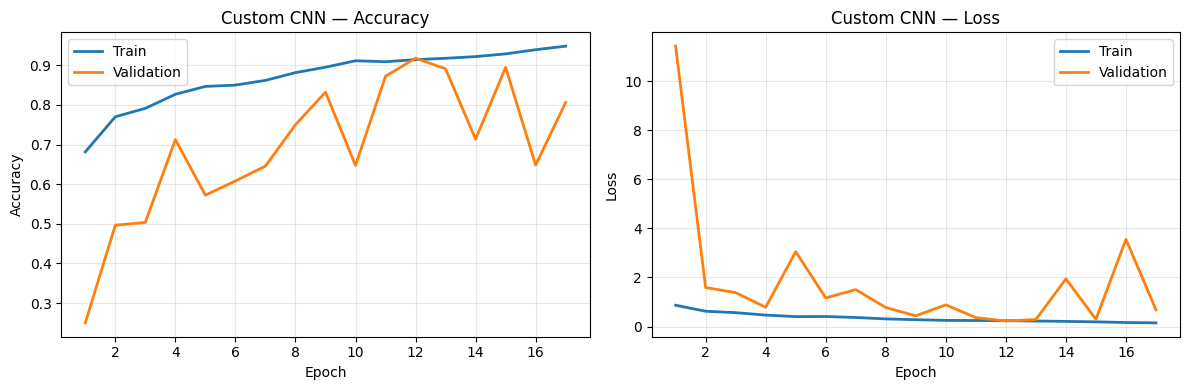

Saved: /content/drive/MyDrive/CS171_BrainTumor/custom_cnn_curves.png


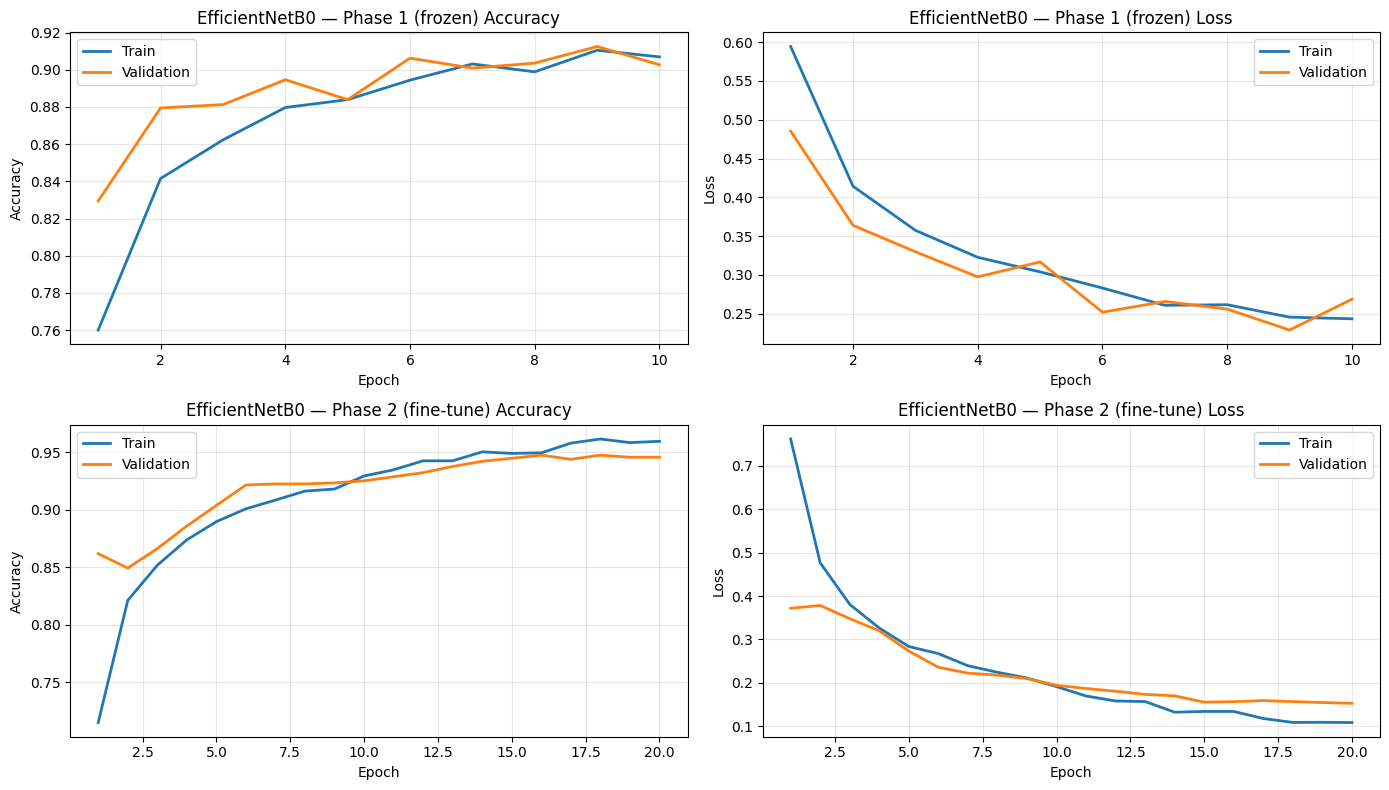

Saved: /content/drive/MyDrive/CS171_BrainTumor/efficientnet_curves.png


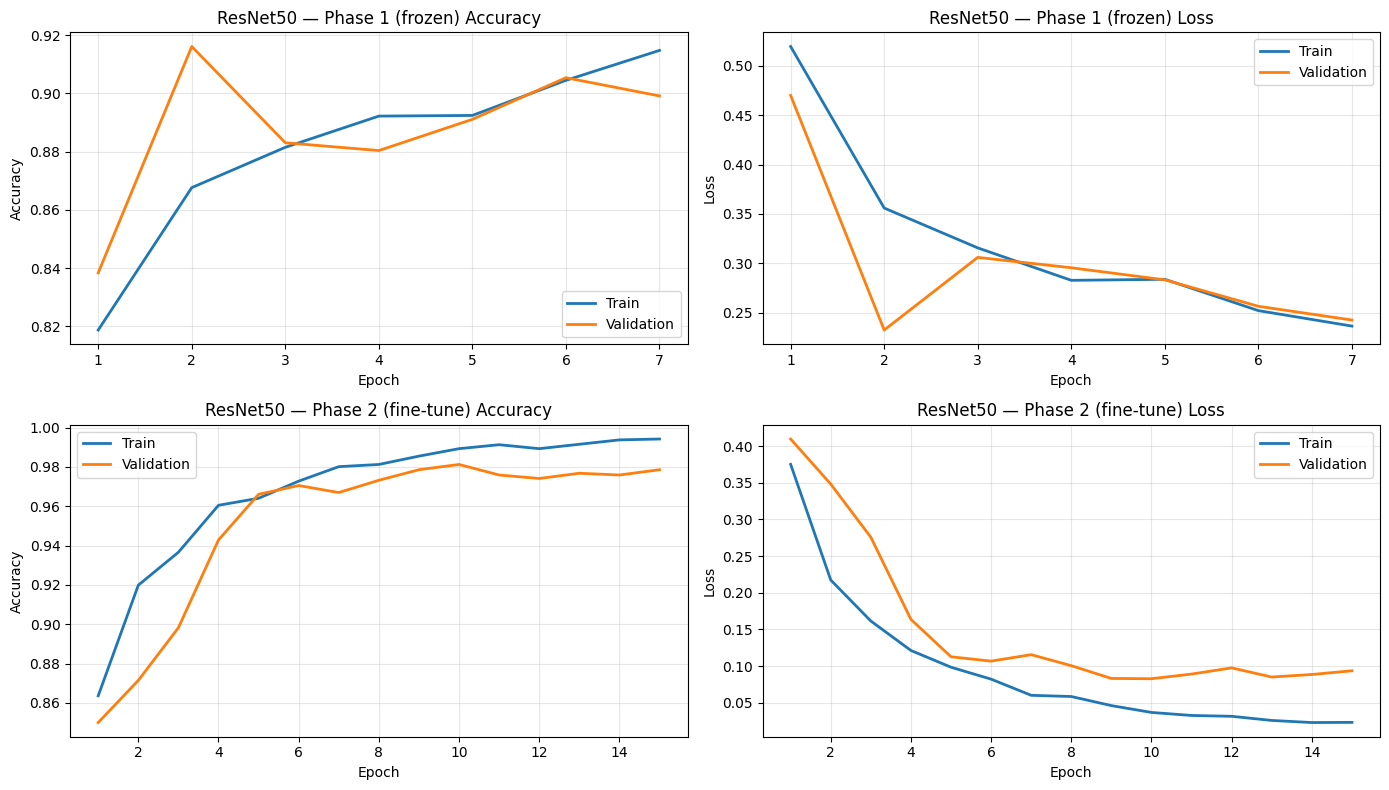

Saved: /content/drive/MyDrive/CS171_BrainTumor/resnet50_curves.png


In [15]:
plot_single_phase(
    cnn_history.history,
    'Custom CNN',
    os.path.join(OUTPUT_DIR, 'custom_cnn_curves.png'),
)

plot_two_phase(
    eff_history_p1.history,
    eff_history_p2.history,
    'EfficientNetB0',
    os.path.join(OUTPUT_DIR, 'efficientnet_curves.png'),
)

plot_two_phase(
    res_history_p1.history,
    res_history_p2.history,
    'ResNet50',
    os.path.join(OUTPUT_DIR, 'resnet50_curves.png'),
)

## 11. Evaluation — All Three Models


Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step

  Custom CNN
              precision    recall  f1-score   support

      glioma       0.96      0.62      0.75       400
  meningioma       0.76      0.79      0.77       400
     notumor       0.78      0.99      0.87       400
   pituitary       0.93      0.97      0.95       400

    accuracy                           0.84      1600
   macro avg       0.86      0.84      0.84      1600
weighted avg       0.86      0.84      0.84      1600

  Test Accuracy : 84.31%
  Macro F1      : 0.8380
Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 75ms/step

  EfficientNetB0
              precision    recall  f1-score   support

      glioma       0.98      0.77      0.86       400
  meningioma       0.88      0.86      0.

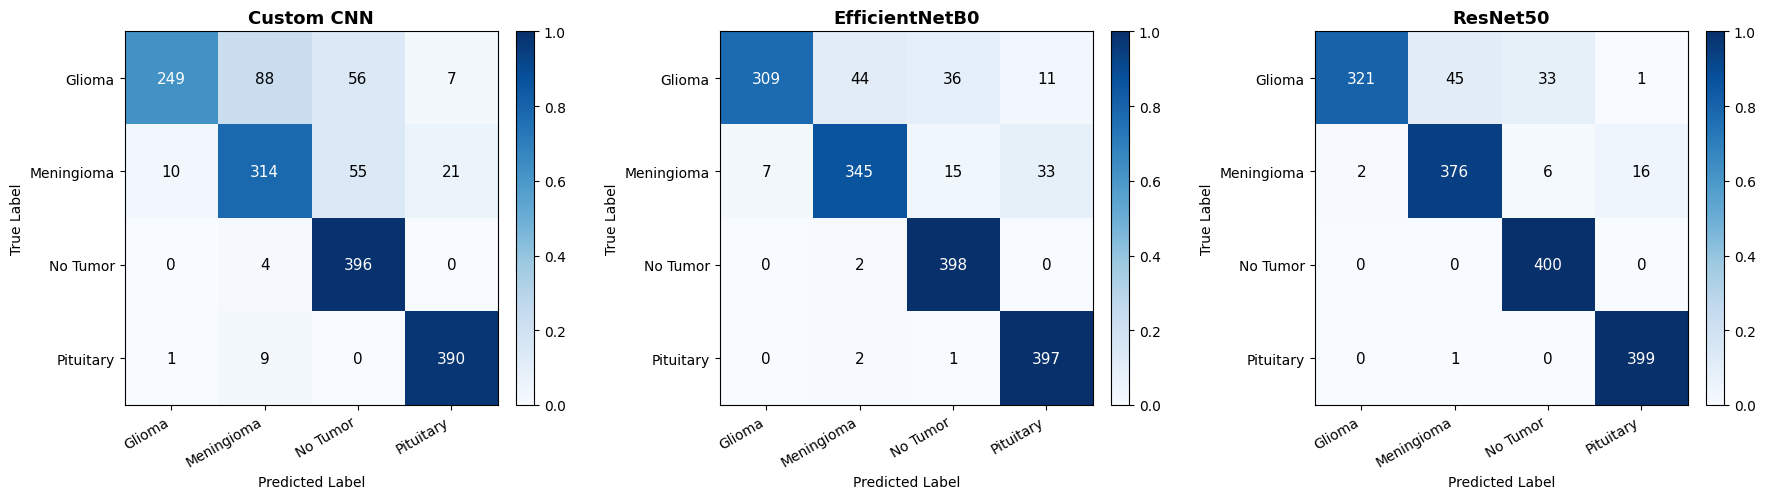

Confusion matrices saved to /content/drive/MyDrive/CS171_BrainTumor/confusion_matrices.png


In [16]:
_, _, test_gen, CLASS_NAMES = get_data_loaders()

cnn_y_true, cnn_y_pred = get_predictions(cnn_model, test_gen)
cnn_acc, cnn_f1 = print_metrics(cnn_y_true, cnn_y_pred, CLASS_NAMES, 'Custom CNN')

_, _, test_gen, CLASS_NAMES = get_data_loaders()
eff_y_true, eff_y_pred = get_predictions(eff_model, test_gen)
eff_acc, eff_f1 = print_metrics(eff_y_true, eff_y_pred, CLASS_NAMES, 'EfficientNetB0')

_, _, test_gen, CLASS_NAMES = get_data_loaders()
res_y_true, res_y_pred = get_predictions(res_model, test_gen)
res_acc, res_f1 = print_metrics(res_y_true, res_y_pred, CLASS_NAMES, 'ResNet50')

cms         = [confusion_matrix(cnn_y_true, cnn_y_pred),
               confusion_matrix(eff_y_true, eff_y_pred),
               confusion_matrix(res_y_true, res_y_pred)]
model_names = ['Custom CNN', 'EfficientNetB0', 'ResNet50']

plot_confusion_matrices(
    cms, CLASS_NAMES, model_names,
    os.path.join(OUTPUT_DIR, 'confusion_matrices.png'),
)

## 12. Results Summary

In [17]:
print('\n' + '=' * 57)
print(f'{"Model":<20} {"Test Accuracy":>14} {"Macro F1":>10}')
print('=' * 57)
print(f'{"Custom CNN":<20} {cnn_acc * 100:>13.2f}% {cnn_f1:>10.4f}')
print(f'{"EfficientNetB0":<20} {eff_acc * 100:>13.2f}% {eff_f1:>10.4f}')
print(f'{"ResNet50":<20} {res_acc * 100:>13.2f}% {res_f1:>10.4f}')
print('=' * 57)

summary = {
    'Custom CNN':     {'test_accuracy': float(cnn_acc), 'macro_f1': float(cnn_f1)},
    'EfficientNetB0': {'test_accuracy': float(eff_acc), 'macro_f1': float(eff_f1)},
    'ResNet50':       {'test_accuracy': float(res_acc), 'macro_f1': float(res_f1)},
}
with open(os.path.join(OUTPUT_DIR, 'results_summary.json'), 'w') as f:
    json.dump(summary, f, indent=2)
print('Results saved to', os.path.join(OUTPUT_DIR, 'results_summary.json'))


Model                 Test Accuracy   Macro F1
Custom CNN                   84.31%     0.8380
EfficientNetB0               90.56%     0.9035
ResNet50                     93.50%     0.9336
Results saved to /content/drive/MyDrive/CS171_BrainTumor/results_summary.json
